# APS 7BM Time-resolved Radiography

This program reads DataGrabber oscilloscope files from APS 7BM and computes raster scan maps and spectra.
It's designed to handle very large, high resolution arrays.

    @author Daniel Duke <daniel.duke@monash.edu>
    @copyright (c) 2026 D.Duke
    @license GPL-3.0+
    @version 0.0.1
    @date 26/03/2026
    
    Multiphase Flow Laboratory
    Monash University, Australia


---
Time-Resolved Radiography of Cavitating Nozzle Flow

When: 08/04/2013
Where: 7-BM, APS, Argonne National Lab
Who: Duke, Powell
Detector: Pin Diode, Femto Amp, Yokogawa DLM2000 scope for the BIM and Pin Diode
	  Yokogawa SL1000 scope and Omega Process Controllers for P3,P4 and Massflow

Note:

Scan_*.dat.gz are DataGrabber files from the Windows PC.

The DLM2k scope was set at ~6 MS/s for 20 seconds with a 1 MHz lowpass filter on the PIN channel (1) and the BIM was in channel 3.
The SL1000 scope was set to record the transducer settings and the trigger signal at 1kHz, triggered from the DLM scope.

The Femto amp gain, the conversions from voltage to pressure etc. for the SL1000 readouts, and the conditions for each scan are written in the log book for Cycle_2013_1.

This is raw data; the time-resolved signal needs to be integrated over the orbit time (ie sum up the points over the orbit time).  At 271.554 kHz, the orbit time is 3.68250882us.

---

## Stage 1 . Convert DAT files to HDF5

In [1]:
import glob, os

dg_compressed_files = glob.glob('/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/*.dat.gz')

file_path = os.path.dirname(dg_compressed_files[0])+'/'

In [18]:

# minor changes made to Alan's code to import, handle duplicate keys, and compressed input and output.
from Python_Library import DataGrabbertoHDF5_Multiprocess as DGtoHDF

DGtoHDF.file_path=file_path

# Process all .dat.gz files
for dg_file in dg_compressed_files:

    h5_file = os.path.basename(dg_file).replace('.dat.gz','.h5')
    print('='*105)
    if os.path.isfile(h5_file): 
        #os.remove(h5_file)
        print("Skipping %s (already exists)" % os.path.basename(h5_file))
    else:
        print(os.path.basename(dg_file))
        # fconvert_file wants only the basename, as abs path specified in file_path
        DGtoHDF.fconvert_file(os.path.basename(dg_file),h5_file)

print("Conversion complete.")

Scan_795.dat.gz
FileType=DataGrabberBinary X=-0.239000 Y=0.099950 NumberOfChannels=6 TimeStamp=2013-Apr-08_17:43:38 ClockTicks=1000000 BIM=2642 PINDiode=21727 I0_APD=0 APSRingCurrent=102.0581 GasBottlePressure(psig)=1168.00183 PSBarometricPressure(psia)=14.2254 7BMMonoEnergy(keV)=8.0019 AccumChargePressure=12.4215 DrainVesselPressure=0.6130 InputT=26.1041 OutputT=26.7989









FileType=DataGrabberBinary X=-0.202000 Y=0.099950 NumberOfChannels=6 TimeStamp=2013-Apr-08_17:44:44 ClockTicks=1000000 BIM=2637 PINDiode=21386 I0_APD=0 APSRingCurrent=101.8489 GasBottlePressure(psig)=1166.17075 PSBarometricPressure(psia)=14.2257 7BMMonoEnergy(keV)=8.0019 AccumChargePressure=12.3844 DrainVesselPressure=0.6169 InputT=26.2204 OutputT=26.7255









FileType=DataGrabberBinary X=-0.002000 Y=0.099950 NumberOfChannels=6 TimeStamp=2013-Apr-08_17:45:50 ClockTicks=1000000 BIM=2630 PINDiode=21945 I0_APD=0 APSRingCurrent=101.6404 GasBottlePressure(psig)=1166.01816 PSBarometricPressure(psia)=14.2260 7BMM

/Users/dduke/src/jupyterNotebooks/Research/TimeresolvedRadiography/Python_Library/readdatagrabber.py:186: RuntimeWarning: invalid value encountered in multiply
  self.data = scale_value * self.data + offset_value


Working on position # 1, position [-0.202, 0.09995]
Replicate # 0
Working on position # 2, position [-0.002, 0.09995]
Replicate # 0
Working on position # 3, position [0.198, 0.09995]
Replicate # 0
Working on position # 4, position [0.236, 0.09995]
Replicate # 0
Working on position # 5, position [-0.2395, 0.5999]
Replicate # 0
Working on position # 6, position [-0.202, 0.5999]
Replicate # 0
Working on position # 7, position [-0.002, 0.5999]
Replicate # 0
Working on position # 8, position [0.198, 0.5999]
Replicate # 0
Working on position # 9, position [0.236, 0.5999]
Replicate # 0
Working on position # 10, position [-0.2395, 1.19995]
Replicate # 0
Working on position # 11, position [-0.202, 1.19995]
Replicate # 0
Working on position # 12, position [-0.002, 1.19995]
Replicate # 0
Working on position # 13, position [0.198, 1.19995]
Replicate # 0
Working on position # 14, position [0.236, 1.19995]
Replicate # 0
Working on position # 15, position [-0.2395, 1.9999]
Replicate # 0
Working on po

---
## Stage 2. Bin the time-series and remove the bunch-charge variations

We just want one data point per synchrotron pulse to give ~6.5 MHz time resolution.

In [1]:
import h5py, os, glob, time
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
%matplotlib widget

file_path='/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM'
hdf5_files = glob.glob(file_path+'/*.h5')

In [2]:
import sys
cython_lib_dir='/Users/dduke/src/jupyterNotebooks/Research/TimeresolvedRadiography/Python_Library'
if not cython_lib_dir in sys.path:
    print("Added to sys.path")
    sys.path.insert(1, cython_lib_dir)

from Python_Library import ArrayBinModule

Added to sys.path


### Load sample data to determine appropriate settings

In [59]:
with h5py.File(hdf5_files[0],'r') as H:
    
    data = H['PINDiode'][0,:,:]
    I0 = H['BIM'][0,:,:]
    
    print("PINDiode array size:",data.shape)
    for k in H['PINDiode'].attrs.keys():
        print ('\t',k, H['PINDiode'].attrs[k])
        
    dt = float(H['PINDiode'].attrs['TimeStep'])
    t0 = float(H['PINDiode'].attrs['FirstPointTime'])
    c_ = float(H['PINDiode'].attrs['Offset'])
    m_ = float(H['PINDiode'].attrs['Scale'])

    c0 = float(H['BIM'].attrs['Offset'])
    m0 = float(H['BIM'].attrs['Scale'])


    
# time axis
t=np.arange(len(data))*dt + t0

PINDiode array size: (125000000, 2)
	 BinaryDataType short
	 Channel 4
	 DAQDevice YokogawaScope2_710130_Ch1
	 DIMENSION_LABELS ['Location' 'Time' 'Replicates']
	 DynamicRangeBits 16
	 FPointer 16510941644
	 FirstPointTime 0.0
	 NumAverages None
	 Offset 0.23
	 RecordLength 125000000
	 Scale 3.125E-6
	 TimeStep 1.6E-7
	 UserDescription PINDiode
	 Volts Scale*ADCValue+Offset


### Summary of AK's functions

**def fbin_signal_fixed_time(input_array,delta_t,pulse_time=None,repeat_num=None,start_time=0)**

Function to read in signal, binning by fixed bin time bin_time.

Inputs:
- input_array: array of input data.
- delta_t: time period between measurement points in the original array.
- pulse_time: Initial estimate of the time between pulses.
- repeat_num: if the pulses have a repeating pattern, how many pulses per period.
- start_point: where should integration begin.

Outputs:
- output_data: binned signal 
- pulse_time: updated measurement of the time between pulses
- start_point * delta_t: where did we really begin integration

**def fbin_signal_by_pulse(input_array,delta_t,pulse_time=None,repeat_num=1,start_time=0)**

Bin a peaked signal with a regular period by each peak.  

Code finds the peak spacing.  Peaks need not be at integer spacing.

Inputs:
- input array: array of peaked input data.
- delta_t: time period between measurement points in the original array.
- pulse_time: Initial estimate of the time between pulses.
- repeat_num: if the pulses have a repeating pattern, how many pulses per period.
- start_time: where should integration begin.  Only here to match fbin_signal_fixed_time

Outputs:
- output_data: binned signal 
- pulse_time: updated measurement of the time between pulses
- start_point * delta_t: where did we really begin integration
    

### Find optimal pulse_time

It should be about 153ns in 24-bunch mode, but we want to minimise aliasing.

In [50]:
# Find optimal pulse_time to minimise aliasing, should be close to 153ns in 24-bunch mode

pulse_time_default=1./271554./24. # should be this.
x=np.linspace(pulse_time_default*.95, pulse_time_default*1.1, 50) # scan around near default.
diffs=[]

def bin_one(x_): # function to run fixed time analysis for a given pulse time
    repeat_num=24
    start_time=0
    pulse_time=x_ #1./271554./24.
    
    output_data, pulse_time2, start_point = ArrayBinModule.fbin_signal_fixed_time(data[:,0].astype(np.float64),\
                                                                      dt,pulse_time,repeat_num,start_time)
    return np.nanmean(np.diff(output_data)**2)**.5

diffs = Parallel(n_jobs=1,verbose=20)(delayed(bin_one)(x_) for x_ in x)

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:    9.7s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:   20.7s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:   30.9s
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:   39.4s
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:   48.1s
[Parallel(n_jobs=1)]: Done   6 tasks      | elapsed:   56.7s
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:  1.1min
[Parallel(n_jobs=1)]: Done   8 tasks      | elapsed:  1.2min
[Parallel(n_jobs=1)]: Done   9 tasks      | elapsed:  1.4min
[Parallel(n_jobs=1)]: Done  10 tasks      | elapsed:  1.5min
[Parallel(n_jobs=1)]: Done  11 tasks      | elapsed:  1.7min
[Parallel(n_jobs=1)]: Done  12 tasks      | elapsed:  1.8min
[Parallel(n_jobs=1)]: Done  13 tasks      | elapsed:  1.9min
[Parallel(n_jobs=1)]: Done  14 tasks      | elapsed:  2.1min
[Parallel(n_jobs=1)]: Done  15 tasks      | elapsed:  2.2min
[Parallel(n_jobs=1)]: Done  16 tasks      | elapsed:  2.3min
[Parallel(n_jobs=1)]: Do

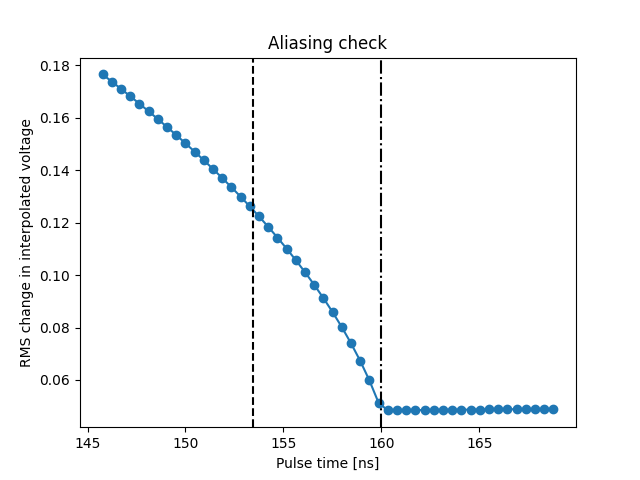

In [51]:
fig=plt.figure()
plt.plot(x*1e9, diffs, marker='o');
plt.xlabel("Pulse time [ns]")
plt.ylabel("RMS change in interpolated voltage")
plt.title("Aliasing check")
plt.axvline(pulse_time_default*1e9,c='k',ls='--');
plt.axvline(dt*1e9,c='k',ls='-.');

In [89]:
test=np.abs(np.diff(diffs)) < 1e-3 
pulse_time = x[np.where(test)[0][0]]
print("Optimal pulse_time = %f ns" % (pulse_time*1e9))
print((1./271554./pulse_time))

Optimal pulse_time = 160.326915 ns
22.968749999999996


In [62]:
# Try the result.

#pulse_time=160.326915e-9 #1/271554./24.
repeat_num=23
start_time=dt*0

t0=time.time()
output_data, pulse_time_out, start_point = ArrayBinModule.fbin_signal_fixed_time(data[:,0].astype(np.float64),\
                                                                      dt,pulse_time,repeat_num,start_time)

print("Completed one timeseries in %f sec. (%i samples)" % (time.time()-t0, len(output_data)))

output_I0, pulse_time_out, start_point = ArrayBinModule.fbin_signal_fixed_time(I0[:,0].astype(np.float64),\
                                                                      dt,pulse_time,repeat_num,start_time)


Completed one timeseries in 9.191382 sec. (124745116 samples)


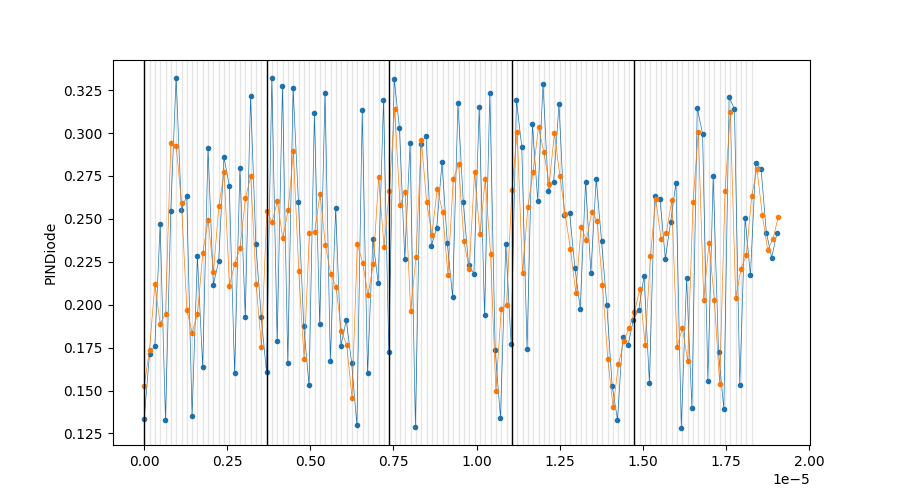

In [83]:
fig=plt.figure(figsize=(9,5))

plt.plot(t[:120], data[:120,0],lw=.5,marker='.')

t_out = np.arange(start_point,start_point+len(output_data)*pulse_time,pulse_time)

plt.plot(t_out[:120], output_data[:120],lw=.5,marker='.')

plt.ylabel('PINDiode')

for n in range(5):
    plt.axvline(n*pulse_time*repeat_num,c='k',lw=1,alpha=1)
    for m in range(repeat_num):
        plt.axvline(n*pulse_time*repeat_num + m*pulse_time,c='k',lw=1,alpha=.1)

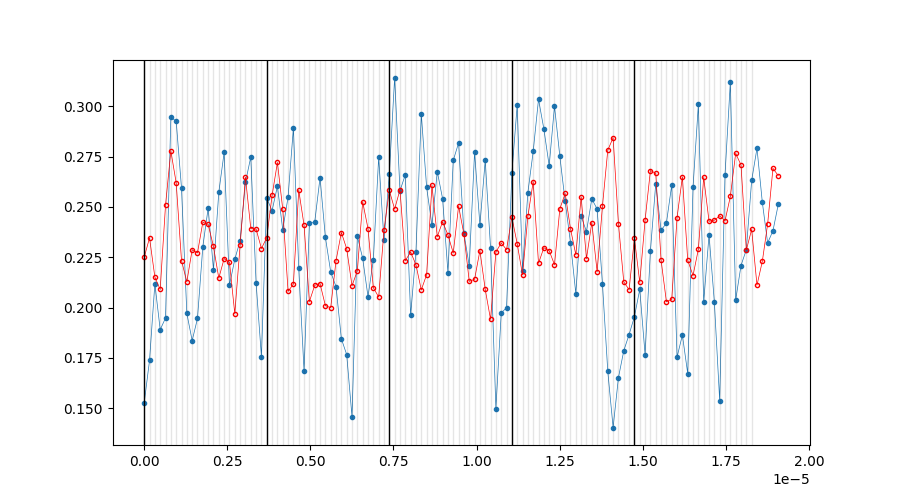

In [82]:
fig=plt.figure(figsize=(9,5))

t_out = np.arange(start_point,start_point+len(output_data)*pulse_time,pulse_time)
plt.plot(t_out[:120], output_data[:120],lw=.5,marker='.')
plt.plot(t_out[:120], output_I0[:120], lw=.5, c='r', marker='o', mfc='None', ms=3)

for n in range(5):
    plt.axvline(n*pulse_time*repeat_num,c='k',lw=1,alpha=1)
    for m in range(repeat_num):
        plt.axvline(n*pulse_time*repeat_num + m*pulse_time,c='k',lw=1,alpha=.1)

### Batch-process data with appropriate settings

Write the binned PIN and BIM data back into the hdf5 files

In [11]:
pulse_time=160.326915e-9 #1/271554./24.
repeat_num=24
start_time=0
skip_processed=True # if False, overwrite.

def process_one(filename, i):
    with h5py.File(filename,'a') as H:

        # Read
        pin = H['PINDiode'][i,...]
        I0 = H['BIM'][i,...]
        dt = float(H['PINDiode'].attrs['TimeStep'])

        if len(pin.shape)>1: pin=pin[:,0]
        if len( I0.shape)>1: I0=I0[:,0]

        # Process
        output_pin, pulse_time_out, start_point = ArrayBinModule.fbin_signal_fixed_time(pin.astype(np.float64),\
                                                                          dt,pulse_time,repeat_num,start_time)

        output_I0, pulse_time_out0, start_point0 = ArrayBinModule.fbin_signal_fixed_time(I0.astype(np.float64),\
                                                                          dt,pulse_time,repeat_num,start_time)

        # Write
        if not 'PIN_binned' in H:
            H.create_dataset('PIN_binned', (H['PINDiode'].shape[0], len(output_pin)), chunks=(1,len(output_pin)),\
                            dtype=np.float64, compression='lzf')
            H['PIN_binned'].attrs['pulse_time']=pulse_time_out
            H['PIN_binned'].attrs['start_point']=start_point
            
        H['PIN_binned'][i,:]=output_pin
        
        if not 'I0_binned' in H:
            H.create_dataset('I0_binned', (H['BIM'].shape[0], len(output_I0)), chunks=(1,len(output_I0)),\
                            dtype=np.float64, compression='lzf')
            H['I0_binned'].attrs['pulse_time']=pulse_time_out0
            H['I0_binned'].attrs['start_point']=start_point0
            
        H['I0_binned'][i,:]=output_I0

    return

In [15]:
for filename in hdf5_files:
    t0=time.time()
    
    # Get size of data
    with h5py.File(filename,'a') as H:
        print(filename)

        # Check if we need to delete previous
        if ('PIN_binned' in H) and skip_processed:
            print("\tFile already processed, skipping to next")
            continue
        else:
            if 'PIN_binned' in H: 
                print("\tOverwriting existing binned arrays")
                del H['PIN_binned']
            if 'I0_binned' in H: del H['I0_binned']

        # Get number of sample points to process
        npts = H['PINDiode'].shape[0]
        
        # Report size of arrays
        print("\tPINDiode array size:",H['PINDiode'].shape)
        print("\tBIM array size:",H['BIM'].shape)

    # Loop over positions - open and close file each time to flush 
    for i in range(npts): # loop serially given large RAM requirement of timeseries. Could be parallelised
        print("\tbinning %i/%i" % (i+1,npts))
        process_one(filename, i)
        
    print("\tcompleted in %.0f s.\n" % (time.time()-t0))

print("all files processed.")

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_797.h5
	File already processed, skipping to next
/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_796.h5
	File already processed, skipping to next
/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_795.h5
	File already processed, skipping to next
/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_798.h5
	File already processed, skipping to next
/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_799.h5
	File already processed, skipping to next
/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_800.h5
	File already processed, skipping to next
/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_801.h5
	File already processed, skipping 

In [14]:
# delete output from a file if required.
with h5py.File('/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_802.h5','a') as H:
    del H['PIN_binned']
    del H['I0_binned']

---
## Stage 3. Compute the spectra

In [2]:
import h5py, os, glob, time
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import scipy.signal
%matplotlib widget

file_path='/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM'
hdf5_files = glob.glob(file_path+'/*.h5')

In [24]:
def process_file(filename, plot_spectra=False):
    pin_spectra_lo = []
    pin_spectra_hi = []
    I0_spectra_lo = []
    I0_spectra_hi = []
    timeavg_stats = []
    t0=time.time()

    
    with h5py.File(filename,'r') as H:
        print(filename)
        
        if 'postprocessed' in H:
            print("\tThis file already processeed. Skipping")
            return
        
        pinData = H['PIN_binned']
        I0Data = H['I0_binned']
        dt = H['PIN_binned'].attrs['pulse_time']

        if len(pinData.shape)>2:
            raise IndexError(str(pinData.shape))

        N = pinData.shape[0]
        for i in range(N):
            print('\t%i / %i' % (i+1,N))
            t0=time.time()
            
            # Time-average
            timeavg_stats.append([ np.nanmean(pinData[i,:]), np.nanstd(pinData[i,:]),\
                                   np.nanmean(I0Data[i,:]), np.nanstd(I0Data[i,:]) ])

            # Spectra (welch method)
            nn=2**20 # big window, low frequencies
            f_lo, P00_lo = scipy.signal.welch(I0Data[i,:],1./dt,nperseg=nn,noverlap=int(nn*3/4))
            f_lo, P11_lo = scipy.signal.welch(pinData[i,:],1./dt,nperseg=nn,noverlap=int(nn*3/4))
            
            nn=2**13 # small window, high frequencies
            f_hi, P00_hi = scipy.signal.welch(I0Data[i,:],1./dt,nperseg=nn)
            f_hi, P11_hi = scipy.signal.welch(pinData[i,:],1./dt,nperseg=nn)

            # Save result to list
            I0_spectra_lo.append(P00_lo)
            I0_spectra_hi.append(P00_hi)
            pin_spectra_lo.append(P11_lo)
            pin_spectra_hi.append(P11_hi)

            time_elapsed = time.time()-t0
            
            # Plot result?
            if plot_spectra:
                fig=plt.figure()
                plt.suptitle(os.path.basename(filename))
                plt.title("i=%i" % i)
                plt.loglog(f_lo,P11_lo,label='PIN = %g ± %g' % tuple(timeavg_stats[-1][:2]),lw=.5)
                plt.loglog(f_lo,P00_lo,label='I0 = %g ± %g' % tuple(timeavg_stats[-1][2:]),lw=.5)
                plt.loglog(f_hi,P11_hi,label='PIN hi',lw=1)
                plt.loglog(f_hi,P00_hi,label='I0 hi',lw=1)
                plt.legend();
            
                print('\tfull f range %.2f-%.2f Hz in %i bins, time record %g s' % (f_lo[1],f_lo[-1],len(f_lo),dt*pinData.shape[1]))
                print('\thigh f range %.2f-%.2f Hz in %i bins, took %.2f s' % (f_hi[1],f_hi[-1],len(f_hi),time_elapsed))

    # Save results from lists to HDF5 back into same file as a new group of datasets.
    with h5py.File(filename,'a') as HO:
        if 'postprocessed' in HO:
            print("\tOverwriting previous result!")
            del HO['postprocessed']
            
        GO = HO.create_group('postprocessed')
        G1 = GO.create_group('spectra_lo')
        G2 = GO.create_group('spectra_hi')
        G3 = GO.create_group('time_avg')
        
        G1.create_dataset('freq',data=f_lo,compression='lzf')
        G2.create_dataset('freq',data=f_hi,compression='lzf')

        d_pin_mean=G3.create_dataset('PIN_mean',(N,),compression='lzf')
        d_I0_mean=G3.create_dataset('I0_mean',(N,),compression='lzf')
        d_pin_std=G3.create_dataset('PIN_std',(N,),compression='lzf')
        d_I0_std=G3.create_dataset('I0_std',(N,),compression='lzf')
        
        
        d_pin_spectra_lo=G1.create_dataset('PIN_spectra',(N,len(pin_spectra_lo[0])),\
                                           chunks=(1,len(pin_spectra_lo[0])), dtype='float64',compression='lzf')

        d_pin_spectra_hi=G2.create_dataset('PIN_spectra',(N,len(pin_spectra_hi[0])),\
                                           chunks=(1,len(pin_spectra_hi[0])), dtype='float64',compression='lzf')

        d_I0_spectra_lo=G1.create_dataset('I0_spectra',(N,len(I0_spectra_lo[0])),\
                                           chunks=(1,len(I0_spectra_lo[0])), dtype='float64',compression='lzf')

        d_I0_spectra_hi=G2.create_dataset('I0_spectra',(N,len(I0_spectra_hi[0])),\
                                           chunks=(1,len(I0_spectra_hi[0])), dtype='float64',compression='lzf')
        
        for i in range(N):
            d_pin_spectra_lo[i,:] = pin_spectra_lo[i]
            d_pin_spectra_hi[i,:] = pin_spectra_hi[i]
            d_I0_spectra_lo[i,:] = I0_spectra_lo[i]
            d_I0_spectra_hi[i,:] = I0_spectra_hi[i]
            d_pin_mean[i] = timeavg_stats[i][0]
            d_pin_std[i] = timeavg_stats[i][1]
            d_I0_mean[i] = timeavg_stats[i][2]
            d_I0_std[i] = timeavg_stats[i][3]
    
    return

In [25]:
for filename in hdf5_files[::-1]:
    print("")
    process_file(filename,plot_spectra=False)
    


/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_799.h5
	This file already processeed. Skipping

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_814.h5
	This file already processeed. Skipping

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_813.h5
	This file already processeed. Skipping

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_812.h5
	1 / 2
	2 / 2

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_811.h5
	1 / 2
	2 / 2

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_810.h5
	1 / 3
	2 / 3
	3 / 3


/var/folders/6z/v83wfyrn4pqdkbl08lfx_pgmvzd0gj/T/ipykernel_51275/4283321074.py:31: RuntimeWarning: Mean of empty slice
  np.nanmean(I0Data[i,:]), np.nanstd(I0Data[i,:]) ])



/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_809.h5
	1 / 2
	2 / 2

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_808.h5
	1 / 2
	2 / 2

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_807.h5
	1 / 2
	2 / 2

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_806.h5
	1 / 1

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_805.h5
	1 / 2
	2 / 2

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_804.h5
	1 / 2
	2 / 2

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_803.h5
	1 / 2
	2 / 2

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_802.h5
	1 / 2
	2 / 2

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Reso

/var/folders/6z/v83wfyrn4pqdkbl08lfx_pgmvzd0gj/T/ipykernel_51275/4283321074.py:30: RuntimeWarning: Mean of empty slice
  timeavg_stats.append([ np.nanmean(pinData[i,:]), np.nanstd(pinData[i,:]),\


	27 / 35
	28 / 35
	29 / 35
	30 / 35
	31 / 35
	32 / 35
	33 / 35
	34 / 35
	35 / 35

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_796.h5
	1 / 35
	2 / 35
	3 / 35
	4 / 35
	5 / 35
	6 / 35
	7 / 35
	8 / 35
	9 / 35
	10 / 35
	11 / 35
	12 / 35
	13 / 35
	14 / 35
	15 / 35
	16 / 35
	17 / 35
	18 / 35
	19 / 35
	20 / 35
	21 / 35
	22 / 35
	23 / 35
	24 / 35
	25 / 35
	26 / 35
	27 / 35
	28 / 35
	29 / 35
	30 / 35
	31 / 35
	32 / 35
	33 / 35
	34 / 35
	35 / 35

/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM/Scan_797.h5
	1 / 34
	2 / 34
	3 / 34
	4 / 34
	5 / 34
	6 / 34
	7 / 34
	8 / 34
	9 / 34
	10 / 34
	11 / 34
	12 / 34
	13 / 34
	14 / 34
	15 / 34
	16 / 34
	17 / 34
	18 / 34
	19 / 34
	20 / 34
	21 / 34
	22 / 34
	23 / 34
	24 / 34
	25 / 34
	26 / 34
	27 / 34
	28 / 34
	29 / 34
	30 / 34
	31 / 34
	32 / 34
	33 / 34
	34 / 34


---

---
## Stage 4. Merge datasets so we have one per experimental condition

Using logbook information.


In [1]:
import h5py, os, glob, time, itertools
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

file_path='/Volumes/DUKE SSD ext4/Older Cavitation Xray data/2013-04-08 Time-Resolved Cavitation 7BM'
hdf5_files = glob.glob(file_path+'/*.h5')

In [2]:
experiment_scans=[(797,798),np.arange(799,803+1),(804,805,808),\
                  np.arange(810,814+1)]
experiments=['P3_10bar__P4_0.5bar','P3_10bar_increasingBackPressure','P3_10bar_decreasingBackPressure',\
            'P3_10bar_increasingBackPressure']

In [ ]:
for i in range(len(experiment_scans)):
    print(experiments[i],'\t:',experiment_scans[i])

    #output file
    HO = h5py.File(os.path.dirname(hdf5_files[0])+'/'+experiments[i]+'.h5','w')
    
    # Find matching files, requiring just that the scan number appears *somewhere* in the filename
    for filename in itertools.chain.from_iterable([ [f for f in hdf5_files if str(n) in os.path.basename(f) ] \
                                                    for n in experiment_scans[i]]):

        
        with h5py.File(filename,'r') as H:
            print('\t',os.path.basename(filename), '\thas',H['X'].shape[0],' points')
            #print('\tP1 ~',np.nanmean(H['AccumChargePressure'][:,0]),'\tP2 ~',np.nanmean(H['DrainVesselPressure'][:,0]))
            print('\t\tx in [',np.nanmin(H['X'][:,0]),np.nanmax(H['X'][:,0]),\
                  ']\ty in [',np.nanmin(H['Y'][:,0]),np.nanmax(H['Y'][:,0]),']')

            GO = HO.create_group(os.path.splitext(os.path.basename(filename))[0])
            
            for k in H.keys():
                if k in ['BIM','BIM 1','PINDiode','PINDiode 1']: 
                    # Do not copy unbinned (raw) signals, no longer needed.
                    print("\t  skip",k)
                else:
                    print("\t  copy",k)
                    H.copy(k, GO)

    HO.close()
    
    print("")
print("Done")
    

---
## Stage 4. Plot the time-average statistics

Use Lambert-Beer law and calibration coefficient from logbook to convert Pin and I0 signal to projected void fraction.

---
## Stage 6. Plot the results

- Spectral integrals
- Transverse average spectra